In [1]:
import sys
!{sys.executable} -m pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Initial Observations

- The dataset contains 8807 rows and 12 columns
- There are missing values in several columns, especially in 'director', 'cast', and 'country'
- The dataset includes both Movies and TV Shows
- Most columns are categorical (text), with only 'release_year' being numerical


In [8]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

In [9]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [11]:
df['date_added'] = df['date_added'].str.strip()

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [13]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [14]:
df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [15]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64

In [16]:
df = df.dropna(subset=['date_added'])

In [17]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [18]:
df['rating'] = df['rating'].fillna("Unknown")
df['duration'] = df['duration'].fillna("Unknown")

In [19]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [20]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

### Movies vs TV Shows

- Netflix content is dominated by Movies, with 6131 titles compared to 2666 TV Shows
- Movies represent a significantly larger portion of the catalog
- This suggests that Netflix has historically focused more on movie content than episodic TV content
- Movies account for approximately 70% of the content, while TV Shows represent about 30%
- This suggests that Netflix has historically prioritized movie content, possibly to quickly expand its catalog and appeal to a broader audience

In [21]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

In [23]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 46.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

In [3]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df = df.dropna(subset=['date_added'])

df['rating'] = df['rating'].fillna("Unknown")
df['duration'] = df['duration'].fillna("Unknown")

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

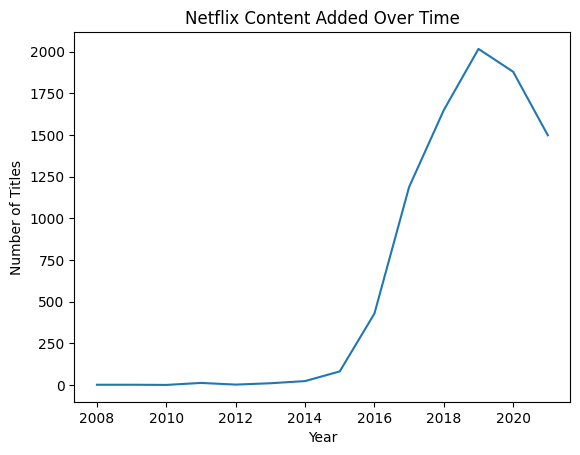

In [4]:
import matplotlib.pyplot as plt

df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Netflix Content Growth Over Time

- Netflix experienced rapid growth in content addition starting around 2016
- The number of titles increased significantly each year, reaching a peak around 2019
- This suggests a period of aggressive expansion in Netflix's content strategy
- After 2020, the number of new titles slightly declined, which may indicate a shift in strategy or external factors affecting production
- The sharp increase after 2016 aligns with Netflix's global expansion and investment in original content

In [5]:
df['country'].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

### Top Countries Producing Netflix Content

- The United States is the dominant content producer on Netflix, with a significantly higher number of titles than any other country
- India ranks second, highlighting the importance of the Indian market in Netflix’s global strategy
- Other countries such as the United Kingdom, Japan, and South Korea also contribute notably to the platform’s content
- This distribution reflects Netflix’s international expansion and investment in diverse, global content
- The strong presence of countries like South Korea and Japan suggests Netflix’s focus on regional content that appeals to both local and global audiences

In [6]:
df[df['country'] != "Unknown"]['country'].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

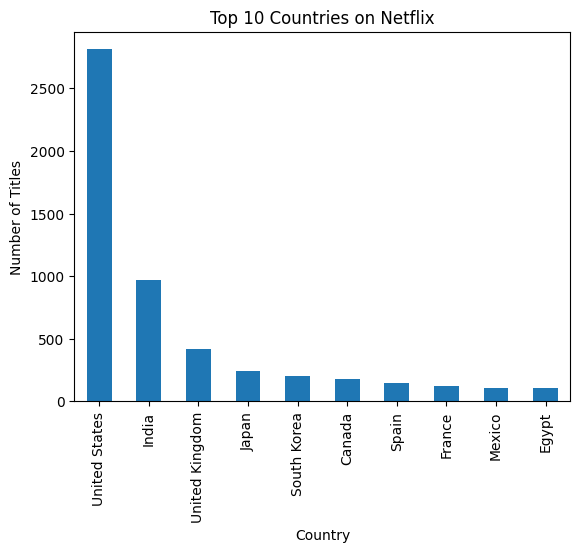

In [9]:
df[df['country'] != "Unknown"]['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

### Top Countries Producing Netflix Content

- The United States is the leading producer of content on Netflix by a large margin
- India ranks second, highlighting its importance in Netflix’s global content strategy
- Other countries like the United Kingdom, Japan, and South Korea also contribute significantly
- This reflects Netflix’s global expansion and focus on diverse international content

In [7]:
df['listed_in'].str.split(', ').explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

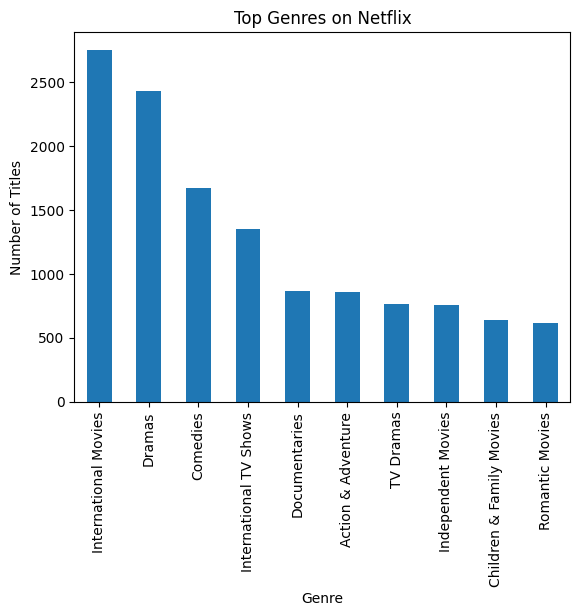

In [8]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()

### Top Genres on Netflix

- International Movies and Dramas are the most common genres on Netflix
- Comedies also represent a large portion of the catalog, indicating strong demand for entertainment content
- The presence of International TV Shows highlights Netflix’s focus on global audiences
- Genres such as Action, Documentaries, and Independent Movies also contribute significantly to content diversity
- The dominance of international content suggests that Netflix prioritizes global reach and localization strategies to attract diverse audiences

In [11]:
df['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

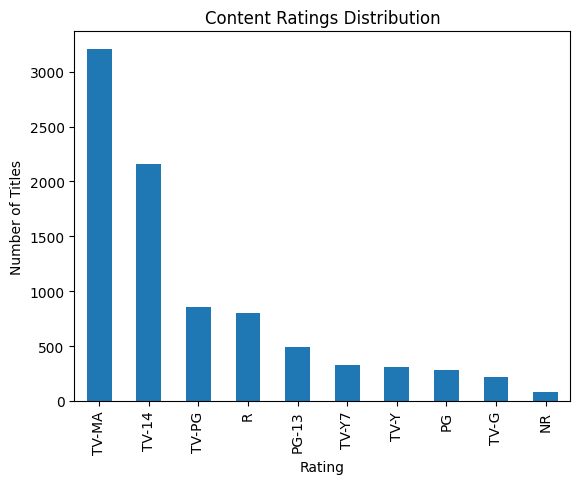

In [12]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

### Content Ratings Distribution

- TV-MA is the most common rating on Netflix, indicating a strong focus on mature content
- TV-14 is the second most frequent rating, showing a significant portion of content targeting teenagers and young adults
- Family-friendly ratings such as PG and TV-G are less represented
- This suggests that Netflix primarily targets adult audiences with its content strategy
- The dominance of mature ratings may reflect Netflix’s strategy to differentiate itself through more complex, edgy, and original content

### Conclusion

- Netflix has significantly expanded its content library, especially after 2016
- Movies dominate the platform, although TV Shows are also an important segment
- The platform emphasizes international content and global markets
- Popular genres include International Movies, Dramas, and Comedies
- Netflix primarily targets mature audiences through its content ratings